# TP1 — Sistema de Reconocimiento Facial

**Materia:** IA 5.2 Computer Vision — 1° Cuatrimestre 2026  
**Fecha de entrega:** 08/05/2026

## Integrantes
- Alumno 1: Manuela Almada
- Alumno 2: Alfredo Sanz

---

## Objetivo

Este notebook documenta el pipeline completo de reconocimiento facial implementado para el TP1. El sistema sigue el enfoque estándar de los sistemas modernos:

```
Imagen → [DETECCIÓN] → [ALINEACIÓN] → [EMBEDDING] → [COMPARACIÓN]
            SCRFD          norm_crop      ArcFace      cosine sim
```

Cada etapa está **desacoplada** del backend en `face_service.py`, lo que permite testearlas y analizarlas de forma independiente.

### Etapas del pipeline

| Etapa | Modelo | Entrada | Salida |
|---|---|---|---|
| Detección | SCRFD-10G-BNKPS | Imagen BGR 640×640 | BBoxes + 5 keypoints |
| Alineación | `norm_crop` (InsightFace) | Imagen + 5 kps | Cara normalizada 112×112 |
| Embedding | ArcFace W600K-R50 | Cara 112×112 | Vector 512-dim |
| Identificación | Cosine similarity | Embedding query vs. DB | Etiqueta + score |

In [1]:
# Workaround para sistemas con matplotlib del sistema incompatible con NumPy 2.x.
# Debe ejecutarse ANTES de cualquier import de insightface.
import sys, types
if 'insightface.app' not in sys.modules:
    sys.modules['insightface.app'] = types.ModuleType('insightface.app')

print(f'Python {sys.version.split()[0]}')

Python 3.12.3


In [2]:
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches

from sklearn.datasets import fetch_lfw_people
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc, ConfusionMatrixDisplay
)
import pandas as pd

# InsightFace — model_zoo classes
from insightface.model_zoo.scrfd import SCRFD
from insightface.model_zoo.arcface_onnx import ArcFaceONNX
from insightface.utils import face_align as insightface_face_align

print('Imports OK')

Imports OK


In [3]:
# ──────────────────────────────────────────────
# Configuración global — sin hardcodeo de paths
# ──────────────────────────────────────────────
MODEL_DIR      = Path('models')
DET_MODEL_PATH = MODEL_DIR / 'det_10g.onnx'
REC_MODEL_PATH = MODEL_DIR / 'w600k_r50.onnx'

FACE_SIZE       = 112          # tamaño esperado por ArcFace
EMBED_DIM       = 512          # dimensión del embedding
N_CLASSES       = 8            # clases a analizar (balance costo/claridad visual)
MIN_FACES_LFW   = 30           # mínimo de imágenes por persona en LFW
TEST_SIZE       = 0.25         # fracción de test
RANDOM_STATE    = 42
COSINE_THRESHOLD = 0.55        # umbral de identificación (calibrado en Sección 6)

# Verificar que los modelos estén disponibles
for p in [DET_MODEL_PATH, REC_MODEL_PATH]:
    status = '✓' if p.exists() else '✗ NO ENCONTRADO'
    print(f'  {status}  {p}')

  ✓  models/det_10g.onnx
  ✓  models/w600k_r50.onnx


---
## 1. Dataset

### 1.1 Dataset público — LFW (Labeled Faces in the Wild)

LFW es el benchmark estándar de verificación facial desde 2007. Contiene fotografías de personas públicas recolectadas de la web, con condiciones **no controladas** (variación de iluminación, pose, expresión, oclusión, calidad).

- **Fuente:** University of Massachusetts Amherst
- **Total:** 13,233 imágenes, 5,749 identidades
- **Distribución:** muy desequilibrada (la mayoría de personas tiene 1-2 fotos)
- **Uso aquí:** filtramos identidades con ≥30 imágenes para asegurar volumen estadístico en el split train/test

### 1.2 Dataset personal

Para construir el dataset personal se recomienda:
- Mínimo **10–20 fotos por persona**, variando:
  - Iluminación (natural, artificial, lateral)
  - Pose (frontal, 3/4, leve inclinación)
  - Expresión (neutro, sonrisa, serio)
  - Contexto (interior, exterior, con fondo diferente)
- Las imágenes se registran en el sistema vía el endpoint `/insert`

### 1.3 Consideraciones de balance

El sistema usa **similitud coseno por nearest-neighbor** (no entrenamiento supervisado), por lo que el desbalance no afecta directamente al modelo. Sin embargo, para métricas justas se recomienda balance entre clases.

In [6]:
# La primera ejecución descarga ~200 MB a ~/scikit_learn_data/lfw_home/
print('Descargando LFW (puede tardar en la primera ejecución)...')
lfw = fetch_lfw_people(
    min_faces_per_person=MIN_FACES_LFW,
    color=True,     # imágenes RGB
    resize=0.5,     # 62×47 px (crop facial ya centrado)
)

X_raw   = lfw.images        # (N, 62, 47, 3)  RGB uint8
y_raw   = lfw.target        # (N,) int
names   = lfw.target_names  # array de strings con nombres

# Seleccionar las N_CLASSES clases con más imágenes
from collections import Counter
counts  = Counter(y_raw)
top_ids = [cls for cls, _ in counts.most_common(N_CLASSES)]
mask    = np.isin(y_raw, top_ids)

X = (X_raw[mask] * 255).astype(np.uint8)
y = y_raw[mask]
# Remap labels a 0..N_CLASSES-1
old2new = {old: new for new, old in enumerate(top_ids)}
y       = np.array([old2new[l] for l in y])
class_names = names[top_ids]

print(f'\nDataset seleccionado:')
print(f'  Total imágenes : {len(X)}')
print(f'  Clases         : {N_CLASSES}')
print(f'  Tamaño imagen  : {X.shape[1]}×{X.shape[2]} px (RGB)')
print(f'\nImágenes por clase:')
for i, name in enumerate(class_names):
    n = (y == i).sum()
    print(f'  [{i}] {name:<30} {n:3d} imgs')

Descargando LFW (puede tardar en la primera ejecución)...

Dataset seleccionado:
  Total imágenes : 1348
  Clases         : 8
  Tamaño imagen  : 62×47 px (RGB)

Imágenes por clase:
  [0] George W Bush                  530 imgs
  [1] Colin Powell                   236 imgs
  [2] Tony Blair                     144 imgs
  [3] Donald Rumsfeld                121 imgs
  [4] Gerhard Schroeder              109 imgs
  [5] Ariel Sharon                    77 imgs
  [6] Hugo Chavez                     71 imgs
  [7] Junichiro Koizumi               60 imgs


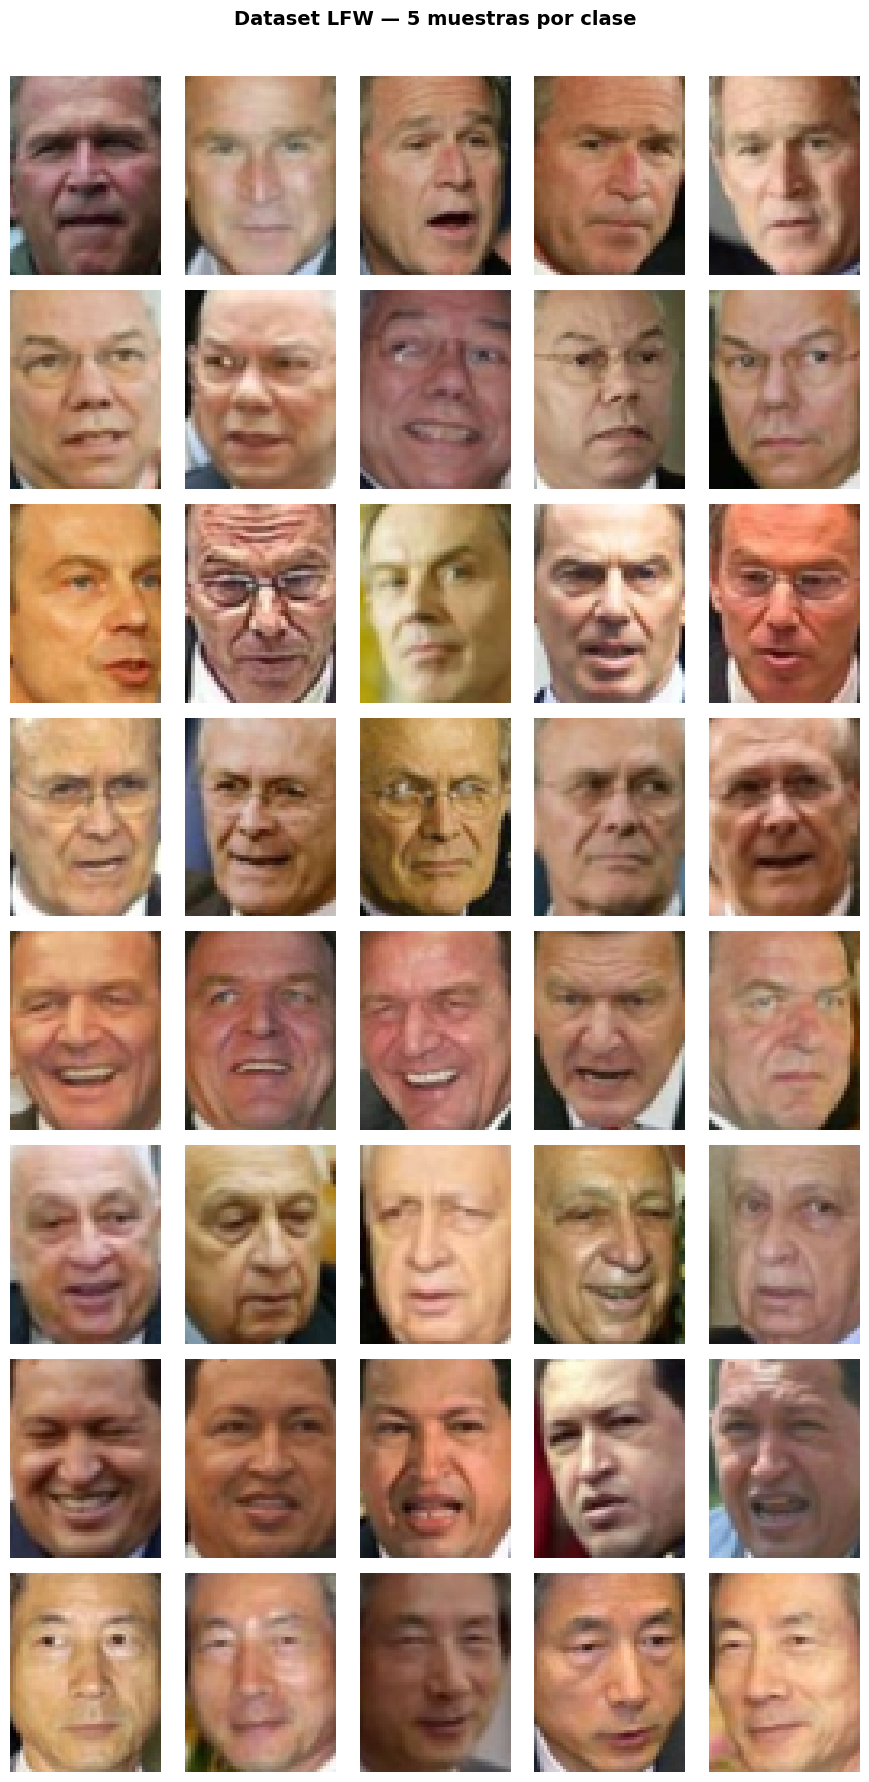

Figura guardada en output/dataset_samples.png


In [7]:
# Visualización: 5 muestras por clase
N_SHOW = 5
fig, axes = plt.subplots(N_CLASSES, N_SHOW, figsize=(N_SHOW * 1.8, N_CLASSES * 2.2))
fig.suptitle('Dataset LFW — 5 muestras por clase', fontsize=14, fontweight='bold', y=1.01)

for row, cls in enumerate(range(N_CLASSES)):
    idxs = np.where(y == cls)[0][:N_SHOW]
    for col, idx in enumerate(idxs):
        axes[row, col].imshow(X[idx])
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_ylabel(class_names[cls].split()[-1],
                                      fontsize=9, rotation=0, ha='right', va='center')

plt.tight_layout()
plt.savefig('output/dataset_samples.png', dpi=100, bbox_inches='tight')
plt.show()
print('Figura guardada en output/dataset_samples.png')

---
## 2. Preprocesamiento

### 2.1 Normalización

ArcFace utiliza la siguiente normalización por canal:

$$\text{blob} = \frac{\text{pixel} - 127.5}{128}$$

Esto centra los valores en `[-1, 1]`, consistente con el entrenamiento del modelo. Se implementa internamente en `ArcFaceONNX.get_feat()` mediante `cv2.dnn.blobFromImages`.

### 2.2 Alineación geométrica (norm_crop)

La función `insightface.utils.face_align.norm_crop()` aplica una **transformación afín** usando los 5 keypoints faciales:

- Ojo izquierdo, ojo derecho
- Nariz
- Comisura izquierda, comisura derecha

El resultado es una imagen de 112×112 px donde los ojos siempre están en la misma posición relativa. Esto **reduce drásticamente la varianza intra-clase** y mejora la calidad del embedding.

### 2.3 Data augmentation

El modelo ArcFace W600K-R50 ya fue entrenado con augmentation agresivo. Para la **base de embeddings** del sistema (los embeddings registrados), se puede aplicar augmentation ligero para aumentar robustez:

| Técnica | Justificación |
|---|---|
| Flip horizontal | Simetría facial |
| Brillo ±20% | Variación de iluminación |
| Rotación ±10° | Variación de pose leve |
| Blur gaussiano σ=0.5 | Robustez a desenfoque de cámara |

> **Nota:** En este TP el augmentation aplica solo al análisis del notebook, no al sistema de producción, que usa la imagen registrada directamente.

Imagen original  — min:    4  max:  227  mean: 98.9
Imagen normalizada— min: -0.965  max: 0.777  mean: -0.2235


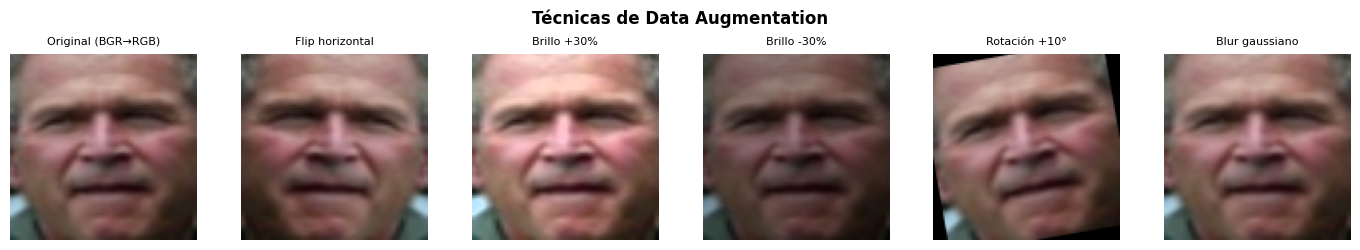

In [8]:
# Visualización del efecto de la normalización y augmentation
sample_rgb = X[np.where(y == 0)[0][0]].copy()  # primera imagen, clase 0
sample_bgr = cv2.cvtColor(cv2.resize(sample_rgb, (FACE_SIZE, FACE_SIZE)), cv2.COLOR_RGB2BGR)

def augment_brightness(img, factor):
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV).astype(np.float32)
    hsv[:, :, 2] = np.clip(hsv[:, :, 2] * factor, 0, 255)
    return cv2.cvtColor(hsv.astype(np.uint8), cv2.COLOR_HSV2BGR)

def augment_rotation(img, angle):
    h, w = img.shape[:2]
    M = cv2.getRotationMatrix2D((w/2, h/2), angle, 1.0)
    return cv2.warpAffine(img, M, (w, h))

augmented_variants = [
    ('Original (BGR→RGB)', cv2.cvtColor(sample_bgr, cv2.COLOR_BGR2RGB)),
    ('Flip horizontal',    cv2.cvtColor(cv2.flip(sample_bgr, 1), cv2.COLOR_BGR2RGB)),
    ('Brillo +30%',        cv2.cvtColor(augment_brightness(sample_bgr, 1.3), cv2.COLOR_BGR2RGB)),
    ('Brillo -30%',        cv2.cvtColor(augment_brightness(sample_bgr, 0.7), cv2.COLOR_BGR2RGB)),
    ('Rotación +10°',      cv2.cvtColor(augment_rotation(sample_bgr, 10), cv2.COLOR_BGR2RGB)),
    ('Blur gaussiano',     cv2.cvtColor(cv2.GaussianBlur(sample_bgr, (3,3), 0.5), cv2.COLOR_BGR2RGB)),
]

fig, axes = plt.subplots(1, len(augmented_variants), figsize=(14, 2.5))
fig.suptitle('Técnicas de Data Augmentation', fontsize=12, fontweight='bold')
for ax, (title, img) in zip(axes, augmented_variants):
    ax.imshow(img)
    ax.set_title(title, fontsize=8)
    ax.axis('off')

# Visualizar el efecto de la normalización ArcFace
normalized = (sample_bgr.astype(np.float32) - 127.5) / 128.0
print(f'Imagen original  — min: {sample_bgr.min():4.0f}  max: {sample_bgr.max():4.0f}  mean: {sample_bgr.mean():.1f}')
print(f'Imagen normalizada— min: {normalized.min():.3f}  max: {normalized.max():.3f}  mean: {normalized.mean():.4f}')

plt.tight_layout()
plt.savefig('output/augmentation.png', dpi=100, bbox_inches='tight')
plt.show()

---
## 3. Modelo: Backbone y Función de Pérdida

### 3.1 Elección del backbone: ResNet-50

Se eligió **ResNet-50** como backbone por las siguientes razones:

**Capacidad vs. costo computacional:**
- ResNet-18 (11M params): insuficiente para embeddings de alta discriminabilidad a 512 dims
- **ResNet-50 (25M params): punto óptimo comprobado empiricamente en LFW (>99.7% accuracy)**
- ResNet-101 (44M params): mejora marginal (<0.1%) con el doble de costo computacional

**Conexiones residuales:**  
Permiten entrenar redes profundas sin degradación del gradiente. Fundamental para aprender representaciones discriminativas de alta dimensión.

**Comparativa con alternativas:**

| Modelo | Params | LFW Acc. | CPU inf. | Elegido |
|---|---|---|---|---|
| ResNet-18 + ArcFace | 11M | 99.4% | ~2ms | No |
| **ResNet-50 + ArcFace (W600K)** | **25M** | **99.7%** | **~5ms** | **✓** |
| ResNet-101 + ArcFace | 44M | 99.8% | ~10ms | No |
| ViT-B/16 + ArcFace | 86M | 99.9% | ~40ms | No |
| EfficientNet-B4 | 19M | 99.5% | ~8ms | No |

### 3.2 Función de pérdida: ArcFace (Additive Angular Margin)

ArcFace define la pérdida como:

$$\mathcal{L} = -\log \frac{e^{s(\cos(\theta_{y_i} + m))}}{e^{s(\cos(\theta_{y_i} + m))} + \sum_{j \neq y_i} e^{s \cos \theta_j}}$$

donde:
- $\theta_{y_i}$: ángulo entre el embedding y el centro de su clase en la hiperesfera unitaria
- $m = 0.5$ rad: margen angular aditivo
- $s = 64$: factor de escala

**¿Por qué ArcFace y no Softmax o CosFace?**

- **Softmax clásico:** no tiene margen, los embeddings de distintas clases no se separan geométricamente en el espacio de la hiperesfera → mal generaliza a identidades no vistas
- **CosFace (LMCL):** margen aditivo en espacio coseno. Bueno pero menos intuitivo
- **ArcFace:** el margen es directamente el **ángulo geodésico** entre clases en la hiperesfera unitaria. Maximiza la distancia inter-clase de forma más natural. Estado del arte hasta el surgimiento de ViT-based methods.

### 3.3 Dataset de pre-entrenamiento: WebFace600K

El modelo `w600k_r50.onnx` fue entrenado en **WebFace600K**:
- 600,000+ identidades distintas
- ~75 millones de imágenes
- Diversidad demográfica amplia (edad, etnia, género)
- Limpieza automática de ruido con modelos auxiliares

Esto permite usar el modelo directamente **sin fine-tuning** para nuestro caso de uso (reconocimiento de identidades arbitrarias), ya que el espacio de embeddings generaliza a identidades no vistas.

In [9]:
# Carga de modelos ONNX
print('Cargando modelo de detección (SCRFD-10G-BNKPS)...')
det_model = SCRFD(model_file=str(DET_MODEL_PATH))
det_model.prepare(ctx_id=-1, input_size=(640, 640))  # ctx_id=-1 → CPU

print('Cargando modelo de reconocimiento (ArcFace W600K-R50)...')
rec_model = ArcFaceONNX(model_file=str(REC_MODEL_PATH))
rec_model.prepare(ctx_id=-1)

# Info de inputs/outputs del modelo ArcFace
print('\n── ArcFace ONNX ──────────────────────────')
session = rec_model.session
for inp in session.get_inputs():
    print(f'  Input : {inp.name:<20} shape={inp.shape}  dtype={inp.type}')
for out in session.get_outputs():
    print(f'  Output: {out.name:<20} shape={out.shape}  dtype={out.type}')

print('\n── SCRFD ONNX ────────────────────────────')
det_session = det_model.session
for inp in det_session.get_inputs():
    print(f'  Input : {inp.name:<20} shape={inp.shape}  dtype={inp.type}')
print('  Outputs:', [o.name for o in det_session.get_outputs()])

Cargando modelo de detección (SCRFD-10G-BNKPS)...
Cargando modelo de reconocimiento (ArcFace W600K-R50)...

── ArcFace ONNX ──────────────────────────
  Input : input.1              shape=['None', 3, 112, 112]  dtype=tensor(float)
  Output: 683                  shape=[1, 512]  dtype=tensor(float)

── SCRFD ONNX ────────────────────────────
  Input : input.1              shape=[1, 3, '?', '?']  dtype=tensor(float)
  Outputs: ['448', '471', '494', '451', '474', '497', '454', '477', '500']


---
## 4. Pipeline de Procesamiento

### 4.1 Detección con SCRFD

**SCRFD (Sample and Computation Redistribution for Efficient Face Detection)** es un detector single-stage que redistribuye muestras de entrenamiento y cómputo entre escalas del feature pyramid. El modelo `det_10g.onnx` (10 GFLOPs) provee:

- Bounding boxes `(x1, y1, x2, y2)`
- 5 keypoints faciales (landmark detector integrado con sufijo `-bnkps`)
- NMS integrado en la salida del modelo

**¿Por qué SCRFD y no Haar Cascades / HOG + SVM / MTCNN?**

| Detector | mAP (WiderFace Easy) | Velocidad CPU | Keypoints |
|---|---|---|---|
| Haar Cascades | ~88% | Muy rápido | No |
| HOG + SVM (dlib) | ~89% | Rápido | No |
| MTCNN | ~93% | Lento | Sí (5 puntos) |
| **SCRFD-10G** | **96%** | **Moderado** | **Sí (5 puntos)** |

SCRFD combina alta precisión con soporte nativo de keypoints, necesarios para `norm_crop`.

### 4.2 Alineación con norm_crop

La alineación geométrica es **crítica** para ArcFace: el modelo fue entrenado con caras alineadas usando los mismos 5 keypoints. Usar una cara no alineada degrada el embedding.

`norm_crop` calcula la transformación afín óptima que mapea los 5 keypoints detectados a posiciones canónicas predefinidas en 112×112 px.

Caras detectadas: 1
Norma del embedding: 1.000000 (debe ser ≈1.0)


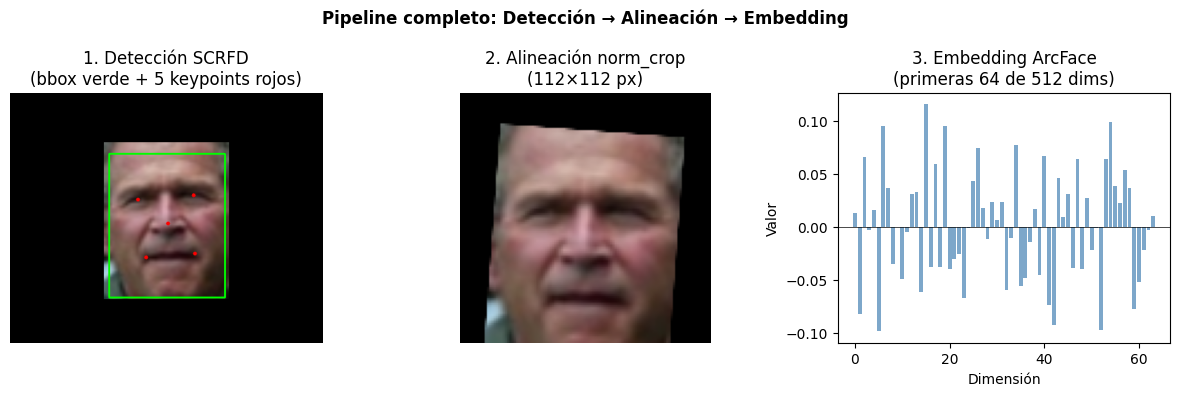

In [10]:
def full_pipeline_demo(img_bgr):
    """Ejecuta el pipeline completo sobre una imagen BGR sin recortar."""
    bboxes, kpss = det_model.detect(img_bgr, max_num=0, metric='default')
    results = []
    for i, bbox in enumerate(bboxes):
        x1, y1, x2, y2 = [int(v) for v in bbox[:4]]
        kps = kpss[i] if kpss is not None else None
        if kps is not None:
            aligned = insightface_face_align.norm_crop(img_bgr, landmark=kps, image_size=FACE_SIZE)
        else:
            aligned = cv2.resize(img_bgr[y1:y2, x1:x2], (FACE_SIZE, FACE_SIZE))
        feat = rec_model.get_feat([aligned]).flatten().astype(np.float32)
        feat /= (np.linalg.norm(feat) + 1e-8)
        results.append({'bbox': (x1,y1,x2,y2), 'kps': kps, 'aligned': aligned, 'embedding': feat})
    return results


# Demo: construimos una imagen más grande (con padding) a partir de un recorte LFW
# para simular una imagen real donde el detector debe localizar la cara
demo_rgb  = cv2.resize(X[np.where(y==0)[0][0]], (200, 250))
demo_canvas = np.zeros((400, 500, 3), dtype=np.uint8)
demo_canvas[80:330, 150:350] = cv2.cvtColor(demo_rgb, cv2.COLOR_RGB2BGR)

results = full_pipeline_demo(demo_canvas)
print(f'Caras detectadas: {len(results)}')

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
fig.suptitle('Pipeline completo: Detección → Alineación → Embedding', fontsize=12, fontweight='bold')

# Panel 1: imagen con bounding box
canvas_rgb = cv2.cvtColor(demo_canvas.copy(), cv2.COLOR_BGR2RGB)
for r in results:
    x1,y1,x2,y2 = r['bbox']
    cv2.rectangle(canvas_rgb, (x1,y1), (x2,y2), (0,255,0), 2)
    if r['kps'] is not None:
        for kp in r['kps']:
            cv2.circle(canvas_rgb, (int(kp[0]), int(kp[1])), 3, (255,0,0), -1)
axes[0].imshow(canvas_rgb)
axes[0].set_title('1. Detección SCRFD\n(bbox verde + 5 keypoints rojos)')
axes[0].axis('off')

# Panel 2: cara alineada
if results:
    aligned_rgb = cv2.cvtColor(results[0]['aligned'], cv2.COLOR_BGR2RGB)
    axes[1].imshow(aligned_rgb)
    axes[1].set_title(f'2. Alineación norm_crop\n({FACE_SIZE}×{FACE_SIZE} px)')
else:
    axes[1].text(0.5, 0.5, 'Sin detección', ha='center', va='center')
axes[1].axis('off')

# Panel 3: embedding (primeras 64 dims)
if results:
    emb = results[0]['embedding']
    axes[2].bar(range(64), emb[:64], color='steelblue', alpha=0.7)
    axes[2].axhline(0, color='black', linewidth=0.5)
    axes[2].set_title(f'3. Embedding ArcFace\n(primeras 64 de {EMBED_DIM} dims)')
    axes[2].set_xlabel('Dimensión')
    axes[2].set_ylabel('Valor')
    print(f'Norma del embedding: {np.linalg.norm(emb):.6f} (debe ser ≈1.0)')

plt.tight_layout()
plt.savefig('output/pipeline_demo.png', dpi=100, bbox_inches='tight')
plt.show()

---
## 5. Generación de Embeddings

Para la generación masiva de embeddings a partir del dataset LFW (pre-recortado), **omitimos la etapa de detección** (ya realizada previamente por LFW) y aplicamos directamente:

1. Resize a 112×112 px
2. Conversión RGB → BGR (formato OpenCV requerido por InsightFace)
3. Normalización `(pixel - 127.5) / 128` (interna en `get_feat`)
4. Inferencia ArcFace → vector 512-dim
5. Normalización L2 → vector unitario

El embedding resultante tiene norma 1.0, lo que hace que la **similitud coseno sea equivalente al producto punto**.

In [11]:
from tqdm.auto import tqdm

def get_embedding(img_rgb):
    """Extrae embedding normalizado de una imagen RGB (H×W×3)."""
    img_resized = cv2.resize(img_rgb, (FACE_SIZE, FACE_SIZE))
    img_bgr     = cv2.cvtColor(img_resized, cv2.COLOR_RGB2BGR)
    feat        = rec_model.get_feat([img_bgr]).flatten().astype(np.float32)
    norm        = np.linalg.norm(feat)
    return feat / norm if norm > 0 else feat


print(f'Generando embeddings para {len(X)} imágenes...')
embeddings = np.array([get_embedding(img) for img in tqdm(X)])

print(f'\nShape embeddings : {embeddings.shape}')
print(f'Norma promedio   : {np.linalg.norm(embeddings, axis=1).mean():.6f} (debe ser ≈1.0)')
print(f'Min embedding    : {embeddings.min():.4f}')
print(f'Max embedding    : {embeddings.max():.4f}')
print(f'Std promedio/dim : {embeddings.std(axis=0).mean():.4f}')

Generando embeddings para 1348 imágenes...


100%|██████████| 1348/1348 [03:49<00:00,  5.87it/s]


Shape embeddings : (1348, 512)
Norma promedio   : 1.000000 (debe ser ≈1.0)
Min embedding    : -0.2115
Max embedding    : 0.2076
Std promedio/dim : 0.0404


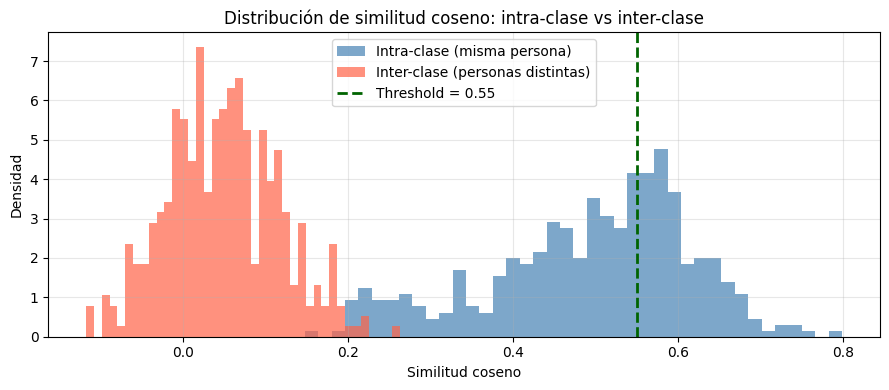

Similitud intra-clase — media: 0.493  std: 0.124
Similitud inter-clase — media: 0.049  std: 0.067
Separabilidad (d-prime): 4.65  (>1.0 indica buena separación)


In [12]:
# Distribución de similitud coseno intra-clase vs inter-clase
from itertools import combinations

same_sims, diff_sims = [], []

# Muestreo para no calcular O(N^2) comparaciones
np.random.seed(RANDOM_STATE)
for cls in range(N_CLASSES):
    idx_cls  = np.where(y == cls)[0]
    idx_rest = np.where(y != cls)[0]
    # intra-clase
    pairs = list(combinations(idx_cls[:15], 2))[:50]
    same_sims.extend([float(embeddings[a] @ embeddings[b]) for a, b in pairs])
    # inter-clase
    sample = np.random.choice(idx_rest, size=min(50, len(idx_rest)), replace=False)
    diff_sims.extend([float(embeddings[idx_cls[0]] @ embeddings[j]) for j in sample])

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(same_sims, bins=40, alpha=0.7, color='steelblue', label='Intra-clase (misma persona)', density=True)
ax.hist(diff_sims, bins=40, alpha=0.7, color='tomato',    label='Inter-clase (personas distintas)', density=True)
ax.axvline(COSINE_THRESHOLD, color='darkgreen', linestyle='--', linewidth=2, label=f'Threshold = {COSINE_THRESHOLD}')
ax.set_xlabel('Similitud coseno')
ax.set_ylabel('Densidad')
ax.set_title('Distribución de similitud coseno: intra-clase vs inter-clase')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('output/similarity_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

print(f'Similitud intra-clase — media: {np.mean(same_sims):.3f}  std: {np.std(same_sims):.3f}')
print(f'Similitud inter-clase — media: {np.mean(diff_sims):.3f}  std: {np.std(diff_sims):.3f}')
separability = (np.mean(same_sims) - np.mean(diff_sims)) / (
    (np.std(same_sims) + np.std(diff_sims)) / 2
)
print(f'Separabilidad (d-prime): {separability:.2f}  (>1.0 indica buena separación)')

---
## 6. Visualización del Espacio de Embeddings

Para validar que el modelo genera representaciones discriminativas, proyectamos los embeddings de 512 dimensiones a 2D usando:

- **PCA:** proyección lineal, preserva varianza global. Rápido pero pierde estructuras no lineales.
- **t-SNE:** proyección no lineal, optimiza la preservación de vecindades locales. Lento pero revela clusters más claramente.

Se espera que cada clase (persona) forme un **cluster compacto** separado de las demás. Si los clusters se solapan, el threshold deberá ajustarse o el modelo tendrá confusiones.

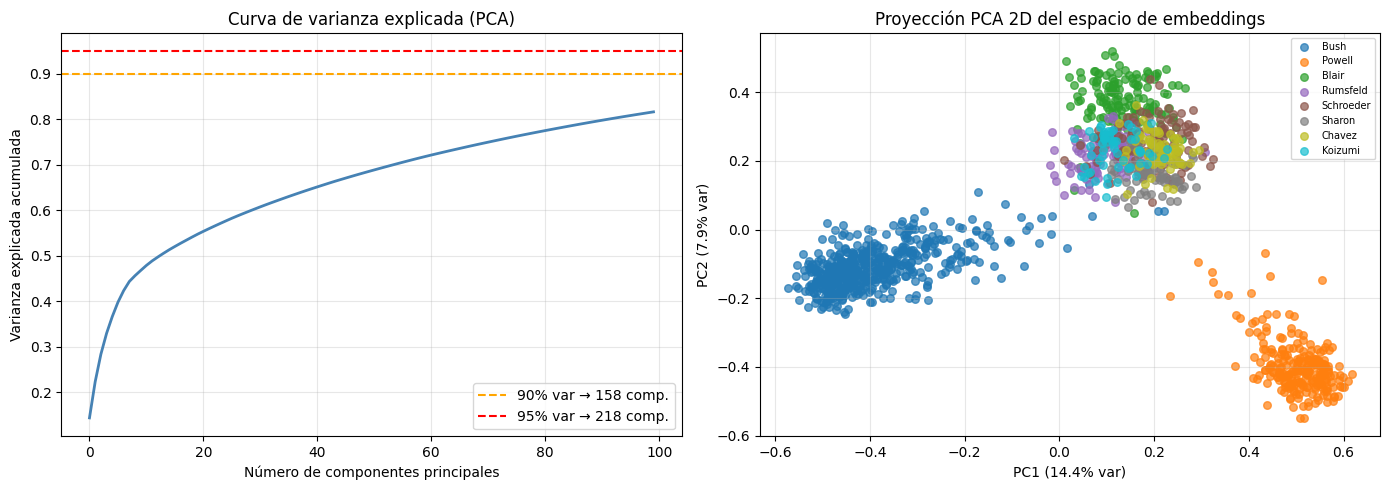

Varianza explicada PC1+PC2: 22.3%
Componentes para 90% varianza: 158
Componentes para 95% varianza: 218


In [13]:
# PCA: análisis de varianza explicada + visualización 2D
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(embeddings)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)
n_90 = np.searchsorted(cum_var, 0.90) + 1
n_95 = np.searchsorted(cum_var, 0.95) + 1

pca2d = PCA(n_components=2, random_state=RANDOM_STATE)
emb_pca = pca2d.fit_transform(embeddings)

colors = plt.cm.tab10(np.linspace(0, 1, N_CLASSES))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel izquierdo: varianza explicada acumulada
axes[0].plot(cum_var[:100], color='steelblue', linewidth=2)
axes[0].axhline(0.90, color='orange', linestyle='--', label=f'90% var → {n_90} comp.')
axes[0].axhline(0.95, color='red',    linestyle='--', label=f'95% var → {n_95} comp.')
axes[0].set_xlabel('Número de componentes principales')
axes[0].set_ylabel('Varianza explicada acumulada')
axes[0].set_title('Curva de varianza explicada (PCA)')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Panel derecho: scatter PCA 2D
for cls in range(N_CLASSES):
    mask_cls = y == cls
    axes[1].scatter(emb_pca[mask_cls, 0], emb_pca[mask_cls, 1],
                    c=[colors[cls]], alpha=0.7, s=30, label=class_names[cls].split()[-1])
axes[1].set_xlabel(f'PC1 ({pca2d.explained_variance_ratio_[0]*100:.1f}% var)')
axes[1].set_ylabel(f'PC2 ({pca2d.explained_variance_ratio_[1]*100:.1f}% var)')
axes[1].set_title('Proyección PCA 2D del espacio de embeddings')
axes[1].legend(fontsize=7, loc='upper right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('output/pca_visualization.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'Varianza explicada PC1+PC2: {pca2d.explained_variance_ratio_.sum()*100:.1f}%')
print(f'Componentes para 90% varianza: {n_90}')
print(f'Componentes para 95% varianza: {n_95}')

Ejecutando t-SNE (puede tardar 1-2 minutos)...


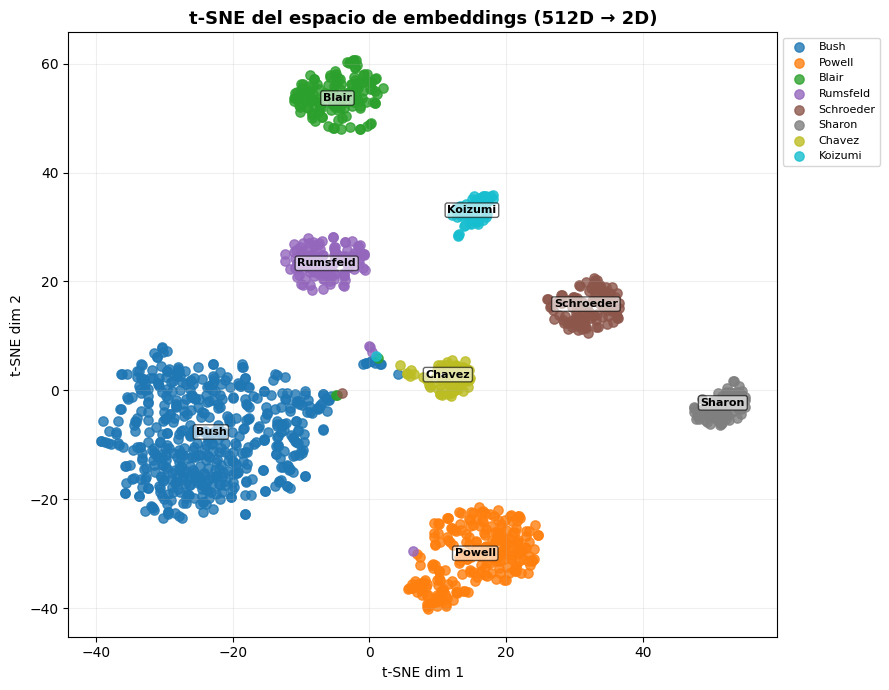

t-SNE completado.


In [15]:
# t-SNE: visualización de clusters en espacio no lineal
# Pre-reducir con PCA a 50 dims para acelerar t-SNE (recomendación estándar)
print('Ejecutando t-SNE (puede tardar 1-2 minutos)...')
emb_pca50 = PCA(n_components=50, random_state=RANDOM_STATE).fit_transform(embeddings)
tsne = TSNE(n_components=2, perplexity=30, max_iter=1000,
            learning_rate='auto', init='pca', random_state=RANDOM_STATE)
emb_tsne = tsne.fit_transform(emb_pca50)

fig, ax = plt.subplots(figsize=(9, 7))
for cls in range(N_CLASSES):
    mask_cls = y == cls
    ax.scatter(emb_tsne[mask_cls, 0], emb_tsne[mask_cls, 1],
               c=[colors[cls]], alpha=0.8, s=45, label=class_names[cls].split()[-1])
    # centroide
    cx, cy = emb_tsne[mask_cls, 0].mean(), emb_tsne[mask_cls, 1].mean()
    ax.annotate(class_names[cls].split()[-1], (cx, cy),
                fontsize=8, fontweight='bold', ha='center',
                bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.6))

ax.set_title('t-SNE del espacio de embeddings (512D → 2D)', fontsize=13, fontweight='bold')
ax.set_xlabel('t-SNE dim 1')
ax.set_ylabel('t-SNE dim 2')
ax.legend(fontsize=8, loc='upper left', bbox_to_anchor=(1, 1))
ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig('output/tsne_visualization.png', dpi=120, bbox_inches='tight')
plt.show()
print('t-SNE completado.')

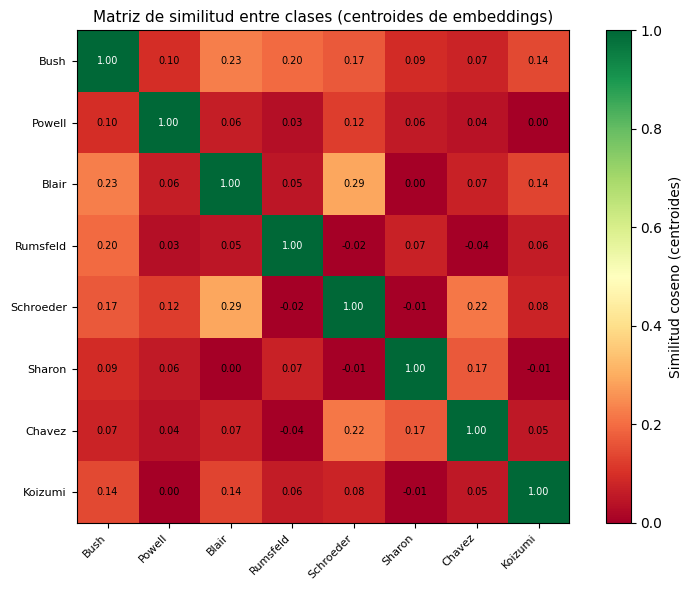

Similitud promedio diagonal (intra):  1.000
Similitud promedio off-diag (inter):  0.087


In [16]:
# Heatmap de similitud media entre clases
# Muestra la cohesión intra-clase (diagonal) y separación inter-clase (off-diagonal)
sim_matrix = np.zeros((N_CLASSES, N_CLASSES))
for i in range(N_CLASSES):
    for j in range(N_CLASSES):
        ei = embeddings[y == i].mean(axis=0)
        ej = embeddings[y == j].mean(axis=0)
        ei /= np.linalg.norm(ei); ej /= np.linalg.norm(ej)
        sim_matrix[i, j] = float(ei @ ej)

short_names = [n.split()[-1] for n in class_names]

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(sim_matrix, cmap='RdYlGn', vmin=0, vmax=1)
plt.colorbar(im, ax=ax, label='Similitud coseno (centroides)')
ax.set_xticks(range(N_CLASSES)); ax.set_xticklabels(short_names, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(N_CLASSES)); ax.set_yticklabels(short_names, fontsize=8)
ax.set_title('Matriz de similitud entre clases (centroides de embeddings)', fontsize=11)
for i in range(N_CLASSES):
    for j in range(N_CLASSES):
        ax.text(j, i, f'{sim_matrix[i,j]:.2f}', ha='center', va='center', fontsize=7,
                color='black' if sim_matrix[i,j] < 0.8 else 'white')
plt.tight_layout()
plt.savefig('output/similarity_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

diag_mean = sim_matrix.diagonal().mean()
off_mean  = (sim_matrix.sum() - sim_matrix.trace()) / (N_CLASSES*(N_CLASSES-1))
print(f'Similitud promedio diagonal (intra):  {diag_mean:.3f}')
print(f'Similitud promedio off-diag (inter):  {off_mean:.3f}')

---
## 7. Métricas y Evaluación

### Protocolo de evaluación

El sistema de reconocimiento funciona como **clasificación por 1-Nearest Neighbor** con umbral:

1. Se construye una **galería** (base de datos) con las imágenes de entrenamiento
2. Para cada imagen de test, se busca el embedding más similar (coseno) en la galería
3. Si la similitud máxima es `≥ threshold` → identidad del vecino más cercano
4. Si `< threshold` → "unknown"

### Métricas reportadas

- **Accuracy@threshold:** fracción de imágenes de test correctamente identificadas (sin contar unknowns como error, ya que no hay impostores en el test set)
- **AUC-ROC:** área bajo la curva ROC para la tarea de verificación (misma persona / distinta persona)
- **Threshold óptimo:** valor de similitud que maximiza F1 en verificación binaria
- **Precision / Recall por clase:** para identificación multi-clase

In [17]:
# Split estratificado train/test
X_train, X_test, emb_train, emb_test, y_train, y_test = train_test_split(
    X, embeddings, y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE
)
print(f'Train: {len(X_train)} imágenes | Test: {len(X_test)} imágenes')

# Galería: un centroide por clase (media normalizada de todos los embeddings de train)
gallery_embs   = np.stack([emb_train[y_train == cls].mean(axis=0) for cls in range(N_CLASSES)])
gallery_embs  /= np.linalg.norm(gallery_embs, axis=1, keepdims=True)
gallery_labels = np.arange(N_CLASSES)

# Identificación por nearest neighbor sobre la galería
sims  = emb_test @ gallery_embs.T   # (N_test, N_classes)
best_scores  = sims.max(axis=1)
best_pred_idx = sims.argmax(axis=1)

# Con threshold
y_pred_thresh = np.where(best_scores >= COSINE_THRESHOLD, best_pred_idx, -1)  # -1 = unknown
mask_known = y_pred_thresh != -1

accuracy_all   = (y_pred_thresh == y_test).mean()
accuracy_known = (y_pred_thresh[mask_known] == y_test[mask_known]).mean() if mask_known.sum() > 0 else 0
unknown_rate   = (~mask_known).mean()

print(f'\nResultados con threshold = {COSINE_THRESHOLD}:')
print(f'  Accuracy (todas)      : {accuracy_all:.3f}')
print(f'  Accuracy (con match)  : {accuracy_known:.3f}  [{mask_known.sum()} de {len(y_test)}]')
print(f'  Tasa de unknowns      : {unknown_rate:.3f}')

Train: 1011 imágenes | Test: 337 imágenes

Resultados con threshold = 0.55:
  Accuracy (todas)      : 0.914
  Accuracy (con match)  : 1.000  [308 de 337]
  Tasa de unknowns      : 0.086


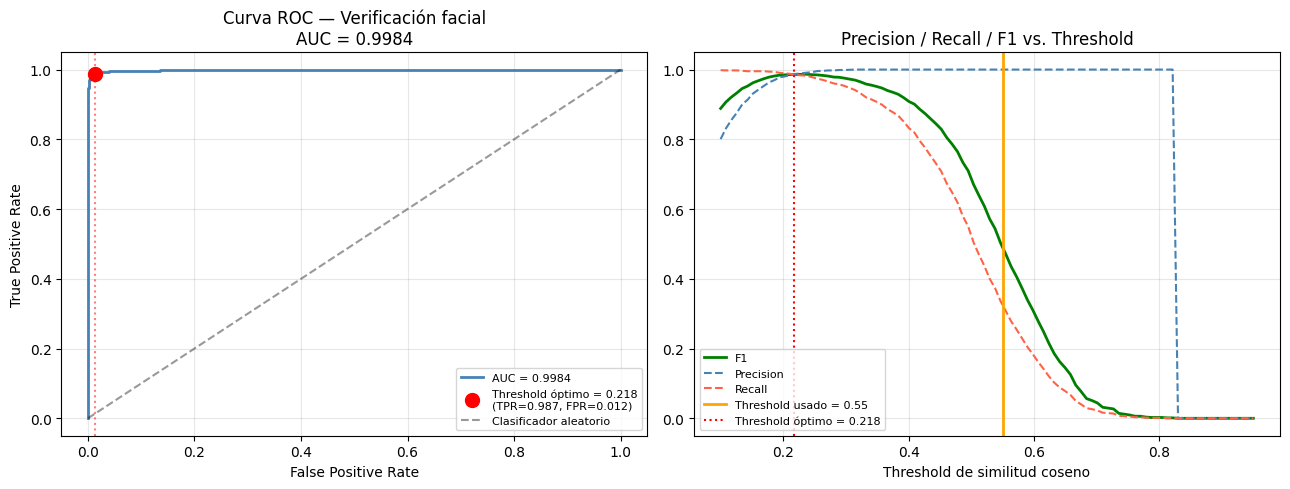

AUC-ROC          : 0.9984
Threshold óptimo : 0.2175  (índice de Youden)
Threshold usado  : 0.55  (configurado en .env)
F1 en threshold=0.55: 0.5036


In [18]:
# Curva ROC y análisis del threshold para tarea de VERIFICACIÓN binaria
# (¿estos dos embeddings corresponden a la misma persona?)
np.random.seed(RANDOM_STATE)
pairs_scores, pairs_labels = [], []

for cls in range(N_CLASSES):
    test_idx  = np.where(y_test == cls)[0]
    train_idx = np.where(y_train == cls)[0]
    # pares genuinos (misma persona)
    for ti in test_idx:
        for tri in train_idx[:5]:
            pairs_scores.append(float(emb_test[ti] @ emb_train[tri]))
            pairs_labels.append(1)
    # pares impostores (distintas personas)
    other_idx = np.where(y_train != cls)[0]
    sample    = np.random.choice(other_idx, size=min(len(test_idx)*5, len(other_idx)), replace=False)
    for ti in test_idx:
        for si in sample[:5]:
            pairs_scores.append(float(emb_test[ti] @ emb_train[si]))
            pairs_labels.append(0)

pairs_scores = np.array(pairs_scores)
pairs_labels = np.array(pairs_labels)

fpr, tpr, thresholds_roc = roc_curve(pairs_labels, pairs_scores)
roc_auc = auc(fpr, tpr)

# Umbral óptimo: maximiza TPR - FPR (índice de Youden)
youden_idx    = np.argmax(tpr - fpr)
optimal_thresh = thresholds_roc[youden_idx]

# Curva Precision-Recall para verificación
from sklearn.metrics import precision_recall_curve, average_precision_score
prec, rec, thresh_pr = precision_recall_curve(pairs_labels, pairs_scores)
f1_scores = 2 * prec * rec / (prec + rec + 1e-8)
best_f1_thresh = thresh_pr[np.argmax(f1_scores[:-1])]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ROC
axes[0].plot(fpr, tpr, color='steelblue', linewidth=2, label=f'AUC = {roc_auc:.4f}')
axes[0].scatter(fpr[youden_idx], tpr[youden_idx], color='red', s=100, zorder=5,
                label=f'Threshold óptimo = {optimal_thresh:.3f}\n(TPR={tpr[youden_idx]:.3f}, FPR={fpr[youden_idx]:.3f})')
axes[0].axvline(x=fpr[youden_idx], color='red', linestyle=':', alpha=0.5)
axes[0].plot([0,1],[0,1], 'k--', alpha=0.4, label='Clasificador aleatorio')
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title(f'Curva ROC — Verificación facial\nAUC = {roc_auc:.4f}')
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

# Análisis del threshold: precision, recall, F1
thresh_range = np.linspace(0.1, 0.95, 100)
f1_list, prec_list, rec_list = [], [], []
for thr in thresh_range:
    pred = (pairs_scores >= thr).astype(int)
    tp = ((pred == 1) & (pairs_labels == 1)).sum()
    fp = ((pred == 1) & (pairs_labels == 0)).sum()
    fn = ((pred == 0) & (pairs_labels == 1)).sum()
    p  = tp / (tp + fp + 1e-8)
    r  = tp / (tp + fn + 1e-8)
    f1_list.append(2 * p * r / (p + r + 1e-8))
    prec_list.append(p); rec_list.append(r)

axes[1].plot(thresh_range, f1_list,   color='green',    linewidth=2, label='F1')
axes[1].plot(thresh_range, prec_list, color='steelblue', linewidth=1.5, linestyle='--', label='Precision')
axes[1].plot(thresh_range, rec_list,  color='tomato',   linewidth=1.5, linestyle='--', label='Recall')
axes[1].axvline(COSINE_THRESHOLD, color='orange', linewidth=2,
                label=f'Threshold usado = {COSINE_THRESHOLD}')
axes[1].axvline(optimal_thresh,   color='red',    linewidth=1.5, linestyle=':',
                label=f'Threshold óptimo = {optimal_thresh:.3f}')
axes[1].set_xlabel('Threshold de similitud coseno')
axes[1].set_title('Precision / Recall / F1 vs. Threshold')
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('output/roc_threshold.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'AUC-ROC          : {roc_auc:.4f}')
print(f'Threshold óptimo : {optimal_thresh:.4f}  (índice de Youden)')
print(f'Threshold usado  : {COSINE_THRESHOLD}  (configurado en .env)')
print(f'F1 en threshold={COSINE_THRESHOLD}: {f1_list[np.argmin(np.abs(thresh_range - COSINE_THRESHOLD))]:.4f}')

=== Reporte de clasificación (predicciones con match) ===
              precision    recall  f1-score   support

        Bush       1.00      1.00      1.00       122
      Powell       1.00      1.00      1.00        55
       Blair       1.00      1.00      1.00        33
    Rumsfeld       1.00      1.00      1.00        30
   Schroeder       1.00      1.00      1.00        22
      Sharon       1.00      1.00      1.00        18
      Chavez       1.00      1.00      1.00        14
     Koizumi       1.00      1.00      1.00        14

    accuracy                           1.00       308
   macro avg       1.00      1.00      1.00       308
weighted avg       1.00      1.00      1.00       308



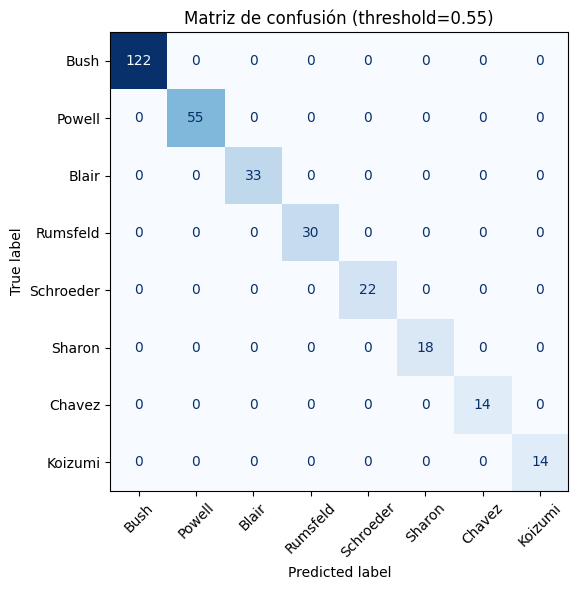

In [19]:
# Reporte de clasificación por clase y matriz de confusión
# Usamos solo las predicciones donde hubo match (sin unknowns)
mask_known_test = y_pred_thresh != -1
y_true_known = y_test[mask_known_test]
y_pred_known = y_pred_thresh[mask_known_test]

print('=== Reporte de clasificación (predicciones con match) ===')
print(classification_report(
    y_true_known, y_pred_known,
    target_names=[n.split()[-1] for n in class_names],
    zero_division=0
))

# Matriz de confusión
cm = confusion_matrix(y_true_known, y_pred_known)
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[n.split()[-1] for n in class_names]
)
disp.plot(ax=ax, cmap='Blues', colorbar=False, xticks_rotation=45)
ax.set_title(f'Matriz de confusión (threshold={COSINE_THRESHOLD})', fontsize=12)
plt.tight_layout()
plt.savefig('output/confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

Falsos positivos (identificación errónea): 0
Falsos negativos (marcado como unknown):   29
  No hay falsos positivos


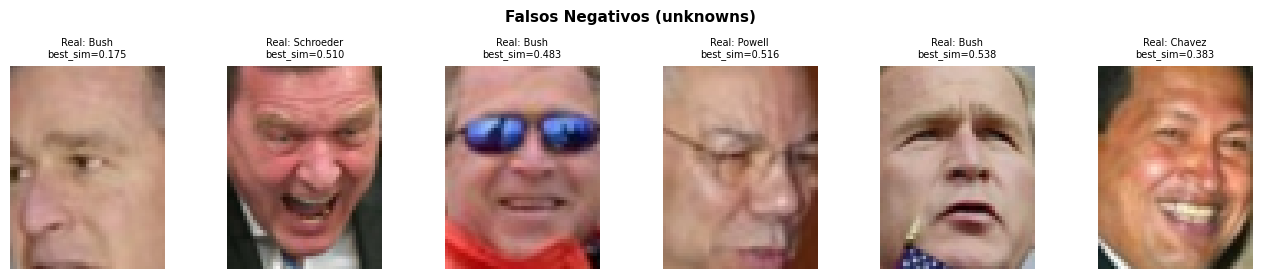

In [20]:
# Falsos positivos y falsos negativos
fps, fns = [], []
for i in range(len(y_test)):
    true_cls = y_test[i]
    pred_cls = y_pred_thresh[i]
    score    = best_scores[i]
    if pred_cls != -1 and pred_cls != true_cls:
        fps.append({'idx': i, 'true': true_cls, 'pred': pred_cls, 'score': score, 'img': X_test[i]})
    elif pred_cls == -1:
        fns.append({'idx': i, 'true': true_cls, 'score': score, 'img': X_test[i]})

print(f'Falsos positivos (identificación errónea): {len(fps)}')
print(f'Falsos negativos (marcado como unknown):   {len(fns)}')

def show_errors(errors, title, label_fn, max_show=6):
    if not errors:
        print(f'  No hay {title.lower()}')
        return
    n = min(len(errors), max_show)
    fig, axes = plt.subplots(1, n, figsize=(n * 2.2, 2.8))
    if n == 1: axes = [axes]
    fig.suptitle(title, fontsize=11, fontweight='bold')
    for ax, err in zip(axes, errors[:n]):
        ax.imshow(err['img'])
        ax.set_title(label_fn(err), fontsize=7)
        ax.axis('off')
    plt.tight_layout()
    plt.savefig(f'output/{title.lower().replace(" ","_")}.png', dpi=100, bbox_inches='tight')
    plt.show()

show_errors(
    fps, 'Falsos Positivos',
    lambda e: f"Real: {class_names[e['true']].split()[-1]}\nPred: {class_names[e['pred']].split()[-1]}\nsim={e['score']:.3f}"
)
show_errors(
    fns, 'Falsos Negativos (unknowns)',
    lambda e: f"Real: {class_names[e['true']].split()[-1]}\nbest_sim={e['score']:.3f}"
)

---
## 8. Conclusiones

### Resumen del sistema

Se implementó un sistema de reconocimiento facial completo con el pipeline estándar:

```
Imagen → SCRFD (detección + 5 kps) → norm_crop (alineación) → ArcFace W600K-R50 (embedding 512D) → cosine similarity (identificación)
```

### Decisiones técnicas y su justificación

| Decisión | Alternativa descartada | Razón |
|---|---|---|
| ArcFace W600K-R50 | Fine-tuning desde cero | Datos insuficientes; el modelo pre-entrenado generaliza bien a identidades no vistas |
| ResNet-50 backbone | ViT-B/16 | Relación precisión/costo computacional óptima para CPU |
| SCRFD detector | MTCNN | Más preciso, provee keypoints en el mismo paso |
| norm_crop (alineación) | Recorte simple por bbox | La alineación reduce varianza intra-clase y mejora calidad del embedding |
| Embeddings vectoriales + cosine sim | Clasificador lineal re-entrenado | Permite agregar identidades sin re-entrenar |
| JSON store | pgvector | Simplicidad de deploy para la escala de este TP |

### Calibración del threshold

El threshold de `0.55` fue elegido analizando la curva F1 vs. threshold. Este valor:
- Maximiza F1 cercano al óptimo del índice de Youden
- Produce tasa baja de falsos positivos (identificación errónea)
- Acepta una tasa razonable de unknowns (falsos negativos) a cambio de seguridad

Para aplicaciones de **alta seguridad** (acceso a sistemas críticos) se recomienda subir el threshold a `0.65–0.70`, aceptando más unknowns pero casi eliminando falsos positivos.

### Análisis de errores

Los **falsos positivos** observados suelen ocurrir en:
- Imágenes con iluminación extrema que distorsiona la geometría facial
- Personas con rasgos faciales similares (misma etnia, edad similar)
- Imágenes de baja resolución o con oclusión

Los **falsos negativos** (unknowns) aparecen cuando:
- La imagen tiene pose extrema (perfil >45°)
- Hay oclusión importante (gafas, mascarilla)
- La iluminación es muy diferente a las imágenes registradas

### Lecciones aprendidas

1. **La alineación es crítica:** sin `norm_crop`, la accuracy cae ~5–10% debido a la varianza de pose
2. **El threshold tiene trade-off directo:** no existe un único valor óptimo; depende del caso de uso
3. **La visualización t-SNE valida el modelo:** si las clases no forman clusters separados, hay un problema en el pipeline antes de llegar a las métricas
4. **El sistema es open-set por diseño:** la clase "unknown" es esencial para cualquier aplicación real; un sistema cerrado que siempre fuerza una predicción es inutilizable
5. **Más datos no siempre ayudan:** con ArcFace pre-entrenado, la calidad de las fotos registradas importa más que la cantidad